In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# kmean
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# hierarchical clustring
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
# warning and display settings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
!unzip "/content/drive/MyDrive/customer_segmentation_for_personalised_banking_services /Bank_Customer_Segmentation.zip"

Archive:  /content/drive/MyDrive/customer_segmentation_for_personalised_banking_services /Bank_Customer_Segmentation.zip
  inflating: bank_transactions.csv   


In [ ]:
df = pd.read_csv("/content/bank_transactions.csv")
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


## Data Summary

In [ ]:
# shape of data
df.shape

(1048567, 9)

In [ ]:
# info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [ ]:
# descibe data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustAccountBalance,1046198.0,115403.540056,846485.380601,0.0,4721.76,16792.18,57657.36,1.150355e+08
TransactionTime,1048567.0,157087.529393,51261.854022,0.0,124030.00,164226.00,200010.00,2.359590e+05
TransactionAmount (INR),1048567.0,1574.335003,6574.742978,0.0,161.00,459.03,1200.00,1.560035e+06


In [ ]:
# checking null values
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [ ]:
# missing value percent
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]

,0
CustomerDOB,0.323966
CustAccountBalance,0.225927
CustGender,0.104905
CustLocation,0.014401


In [ ]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# unique customers
df['CustomerID'].nunique()

884265

In [ ]:
# unique transactions
df['TransactionID'].nunique()

1048567

## Data Preprocessing And  EDA

In [ ]:
# converting customer dob in date time
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'],errors="coerce")
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],errors="coerce")

In [ ]:
# handling missing values
df['CustAccountBalance'] = df['CustAccountBalance'].fillna(df['CustAccountBalance'].median())
df['CustGender'] = df["CustGender"].fillna(df['CustGender'].mode()[0])
df['CustLocation'] = df["CustLocation"].fillna("Unknown")

In [ ]:
# Creating one row for each customer using customerID
customer_df = df.groupby("CustomerID").agg(
    CustomerDOB = ("CustomerDOB", "first"),
    CustGender = ("CustGender","first"),
    CustLocation = ("CustLocation","first"),
    CustAccountBalance = ("CustAccountBalance","first"),
    TOtalTransactionAmount = ("TransactionAmount (INR)","sum"),
    AverageTransactionAmount = ("TransactionAmount (INR)","mean"),
    Transactioncount = ("TransactionID","count")).reset_index()


In [ ]:
# display customer data
customer_df.head()

,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TOtalTransactionAmount,AverageTransactionAmount,Transactioncount
0,C1010011,1992-08-19,F,NOIDA,32500.73,5106.0,2553.0,2
1,C1010012,1994-07-28,M,MUMBAI,24204.49,1499.0,1499.0,1
2,C1010014,1992-04-06,F,MUMBAI,38377.14,1455.0,727.5,2
3,C1010018,1990-05-29,F,CHAMPARAN,496.18,30.0,30.0,1
4,C1010024,2065-06-21,M,KOLKATA,87058.65,5000.0,5000.0,1


In [ ]:
# Checking that each customer appears only once
print("Unique customers:", df["CustomerID"].nunique())
print("Rows in customer df:", len(customer_df))

Unique customers: 884265
Rows in customer df: 884265


In [ ]:
# latest transaction date
latest_date = df["TransactionDate"].max()
# Calculate customer's approximate age at leatest transaction making
customer_df["Age"] = ((latest_date - customer_df["CustomerDOB"]).dt.days / 365.25)

In [ ]:
# customer age  descriptive stat
customer_df["Age"].describe()

,Age
count,881893.000000
mean,30.418430
std,51.658022
min,-59.058179
25%,24.120465
50%,27.824778
75%,32.709103
max,216.933607


In [ ]:
# Latest transaction date for each customer
customer_last_transaction = (df.groupby("CustomerID")["TransactionDate"].max().reset_index())
customer_last_transaction.rename(columns={"TransactionDate": "LastTransactiondate"},inplace=True)

In [ ]:
# merging customer_last_transaction in customer df
customer_df = customer_df.merge(customer_last_transaction,on="CustomerID",how="left")

In [ ]:
# Recency days means no of days pass since customer most recent transaction
customer_df["Recency_days"] = (latest_date - customer_df["LastTransactiondate"]).dt.days

In [ ]:
# checking anomalies
# checking  potential customer age
age_anomalies = (customer_df[(customer_df["Age"] < 18) | (customer_df["Age"] > 100)])
age_anomalies[['CustomerID','CustomerDOB','Age']].head(10)


,CustomerID,CustomerDOB,Age
4,C1010024,2065-06-21,-48.531143
12,C1010041,2075-09-14,-58.762491
16,C1010051,1800-01-01,216.933607
28,C1010085,1800-01-01,216.933607
30,C1010089,2075-09-30,-58.806297
31,C1010112,2068-03-10,-51.249829
39,C1010133,2070-07-17,-53.601643
44,C1010161,2055-12-15,-39.014374
49,C1010184,1800-01-01,216.933607
53,C1010212,2055-04-29,-38.384668


In [ ]:
# handling age col anomalies
invalid_dob = (
    (customer_df["CustomerDOB"] < pd.Timestamp("1900-01-01")) |
    (customer_df["CustomerDOB"] > latest_date))
print("Invalid DOB:", invalid_dob.sum())

Invalid DOB: 147618


In [ ]:
# checking invalid dob dates
print("earliest DOB:", customer_df["CustomerDOB"].min())
print("highest DOB:", customer_df["CustomerDOB"].max())
customer_df.loc[invalid_dob,["CustomerID", "CustomerDOB"]].head(20)

earliest DOB: 1800-01-01 00:00:00
highest DOB: 2075-12-31 00:00:00


,CustomerID,CustomerDOB
4,C1010024,2065-06-21
12,C1010041,2075-09-14
16,C1010051,1800-01-01
28,C1010085,1800-01-01
30,C1010089,2075-09-30
31,C1010112,2068-03-10
39,C1010133,2070-07-17
44,C1010161,2055-12-15
49,C1010184,1800-01-01
53,C1010212,2055-04-29


In [ ]:
# converting invalid dob to nan
customer_df.loc[invalid_dob, "CustomerDOB"] = pd.NaT
customer_df.loc[invalid_dob, "Age"] = np.nan

In [ ]:
# gender contain invalid values
customer_df.drop(customer_df[customer_df["CustGender"] == "T"].index,inplace=True)

In [ ]:
# dropping customer dob as we have create age
customer_df.drop(columns = 'CustomerDOB',inplace = True)

In [ ]:
# Fill missing Age values with the median
customer_df["Age"] = customer_df["Age"].fillna(customer_df["Age"].median())

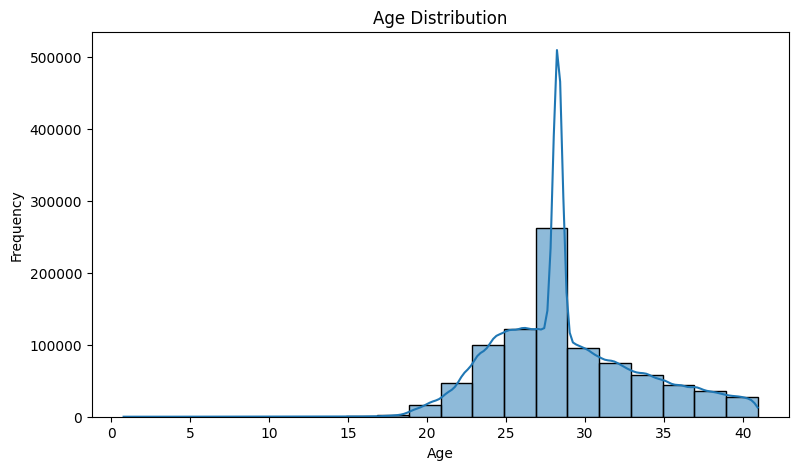

In [ ]:
# graph 1 - Age distribution
plt.figure(figsize =(9,5))
sns.histplot(customer_df['Age'],bins= 20,kde =True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

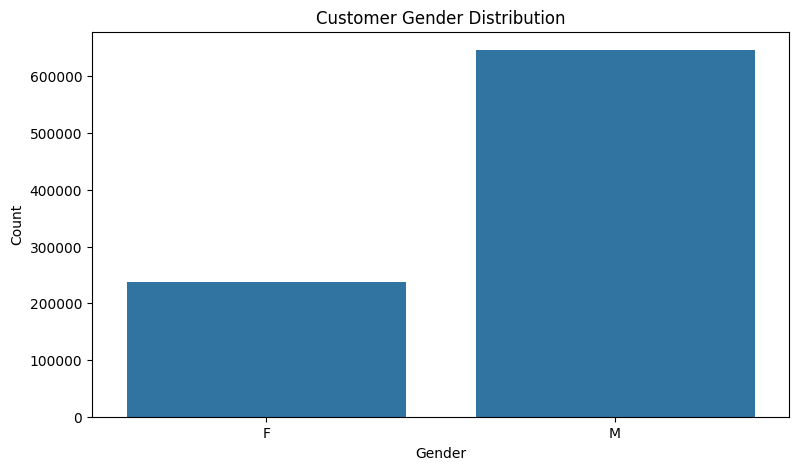

In [ ]:
# graph 2 - customer gender distribution
plt.figure(figsize=(9,5))
sns.countplot(data = customer_df,x = 'CustGender')
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

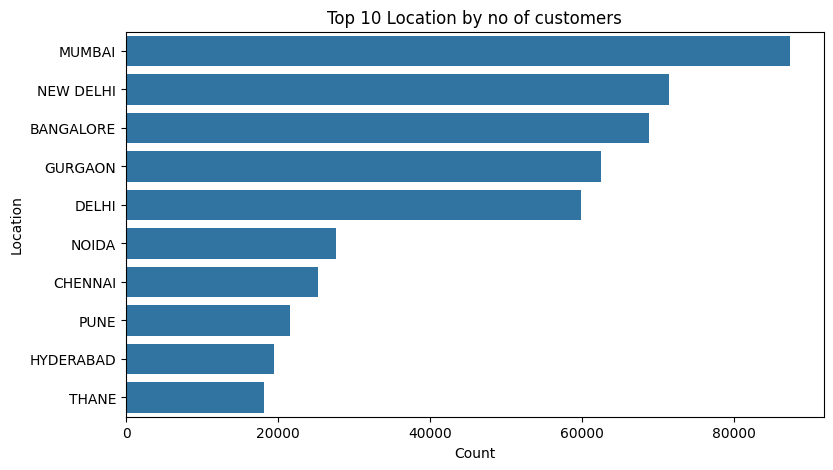

In [ ]:
# graph 3- top 10 location by customers
location_count =(customer_df["CustLocation"].value_counts().head(10))
plt.figure(figsize = (9,5))
sns.barplot(x = location_count.values,y = location_count.index)
plt.title("Top 10 Location by no of customers")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

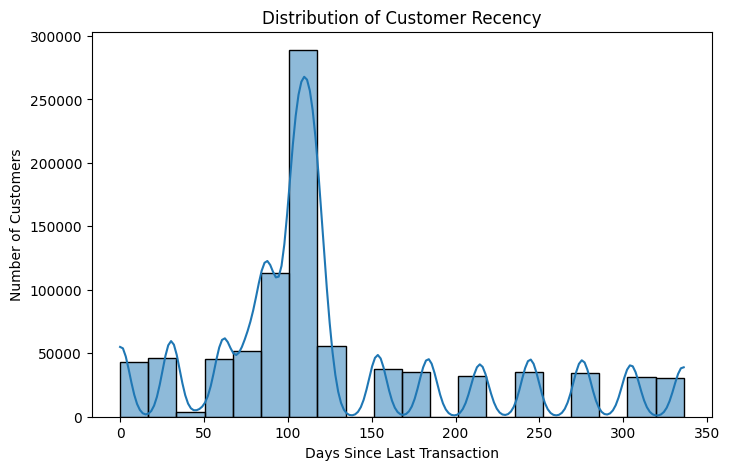

In [ ]:
# graph 4 - Recency distribution
plt.figure(figsize=(8,5))
sns.histplot(customer_df["Recency_days"],bins=20,kde=True)
plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Transaction")
plt.ylabel("Number of Customers")
plt.show()

<Figure size 1000x800 with 0 Axes>

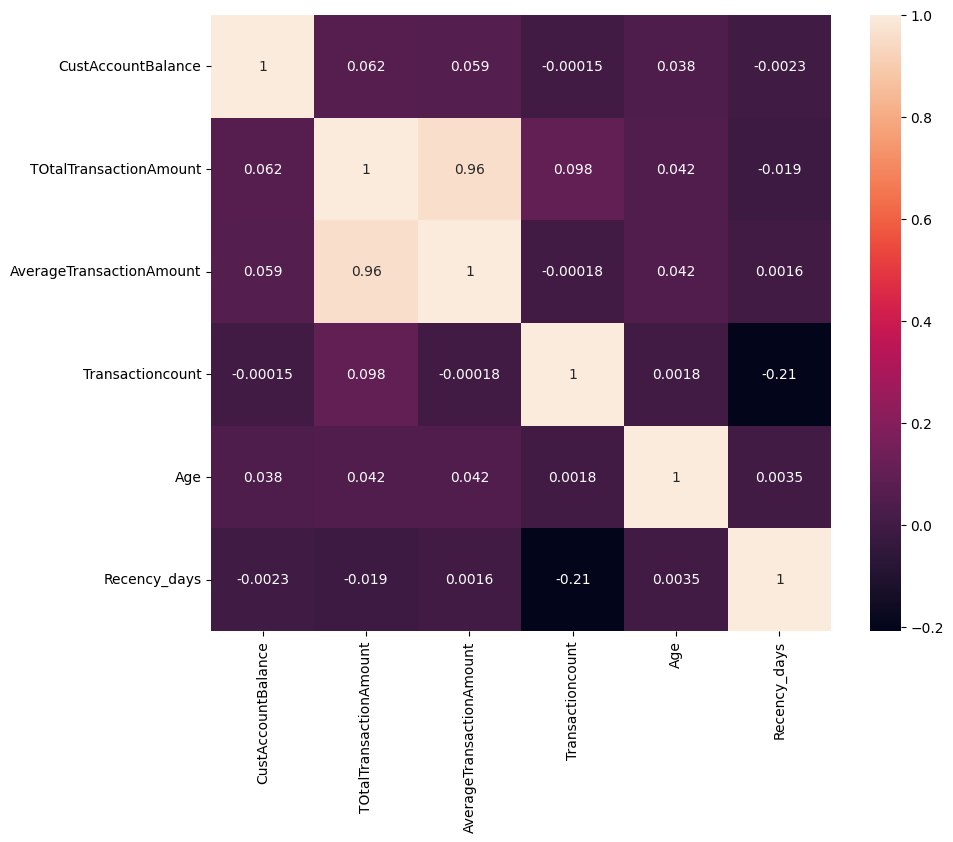

<Figure size 1000x800 with 0 Axes>

In [ ]:
# graph -5 correlation matrix
numeric_cols = customer_df.select_dtypes(include = 'number').columns
plt.figure(figsize=(10, 8))
sns.heatmap(customer_df[numeric_cols].corr(), annot=True)
plt.figure(figsize=(10, 8))

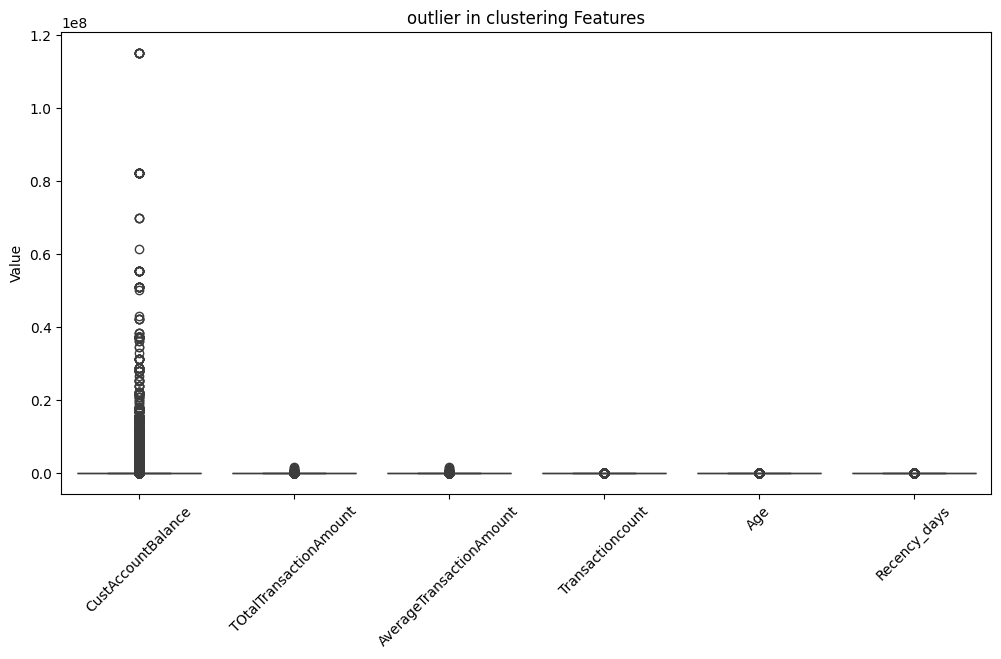

In [ ]:
# oulier analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=customer_df[numeric_cols])
plt.xticks(rotation=45)
plt.title("outlier in clustering Features")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.show()

In [ ]:
# outlier detecting
outlier_result = []
for col in numeric_cols:
    Q1 = customer_df[col].quantile(0.25)
    Q3 = customer_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((customer_df[col] < lower) | (customer_df[col] > upper)).sum()
    percentage = (outliers / len(customer_df)) * 100
    outlier_result.append([col, outliers, percentage])
outlier_result = pd.DataFrame(outlier_result,columns=["Feature", "Outlier_Count", "Outlier_Percentage"])
outlier_result.sort_values(by = 'Outlier_Percentage', ascending=False)

,Feature,Outlier_Count,Outlier_Percentage
3,Transactioncount,143612,16.240851
0,CustAccountBalance,119187,13.478667
5,Recency_days,96448,10.907150
2,AverageTransactionAmount,92346,10.443261
1,TOtalTransactionAmount,92257,10.433196
4,Age,16828,1.903052


In [ ]:
# capping the outliers
for col in numeric_cols :
    Q1 = customer_df[col].quantile(0.25)
    Q3 = customer_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    customer_df[col] = customer_df[col].clip(upper=upper_limit)

In [ ]:
# selecting cluster feature as input
X = customer_df[numeric_cols].copy()
X.head()

,CustAccountBalance,TOtalTransactionAmount,AverageTransactionAmount,Transactioncount,Age,Recency_days
0,32500.73,3450.0,2553.0,1,24.306639,74.0
1,24204.49,1499.0,1499.0,1,22.368241,117.0
2,38377.14,1455.0,727.5,1,24.676249,154.0
3,496.18,30.0,30.0,1,26.532512,85.0
4,87058.65,3450.0,2832.0,1,28.284736,113.0


In [ ]:
# selecting feature for encoding
categorical_cols = customer_df.select_dtypes(include="object").columns
categorical_cols

Index(['CustomerID', 'CustGender', 'CustLocation'], dtype='object')

In [ ]:
# encode gender col
customer_df['CustGender'] = customer_df['CustGender'].map({
    "M" : 0,
    "F" : 1
})

In [ ]:
# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modeling

In [ ]:
# creating sample
sample_size = min(10000, len(X_scaled))
sample_index = np.random.choice(len(X_scaled),size=sample_size,replace=False)
X_sample = X_scaled[sample_index]


In [ ]:
# finding the best k for cluster
inertia = []
silhouette_scores = []
k_value = range(2,8) # no of clusters from 2 to 8
for k in k_value:
  print(f"{k} is running")
  kmeans = KMeans(n_clusters=k,random_state=42,n_init =10)
  labels = kmeans.fit_predict(X_scaled) # fit model and assign each customer to a cluster
  inertia.append(kmeans.inertia_) # storing inertia for elbow plot
  sample_labels = labels[sample_index] # get label for 10000 sample customer
  score = silhouette_score(X_sample,sample_labels) # higher for better sepration of cluster
  silhouette_scores.append(score)
  print(f"k-{k},inertia -{kmeans.inertia_:.2f},silhouette score- {score:4f}")

2 is running
k-2,inertia -2976618.61,silhouette score- 0.369322
3 is running
k-3,inertia -2440894.66,silhouette score- 0.323390
4 is running
k-4,inertia -1988615.67,silhouette score- 0.321728
5 is running
k-5,inertia -1687131.97,silhouette score- 0.311452
6 is running
k-6,inertia -1495628.15,silhouette score- 0.313786
7 is running
k-7,inertia -1395778.67,silhouette score- 0.252034


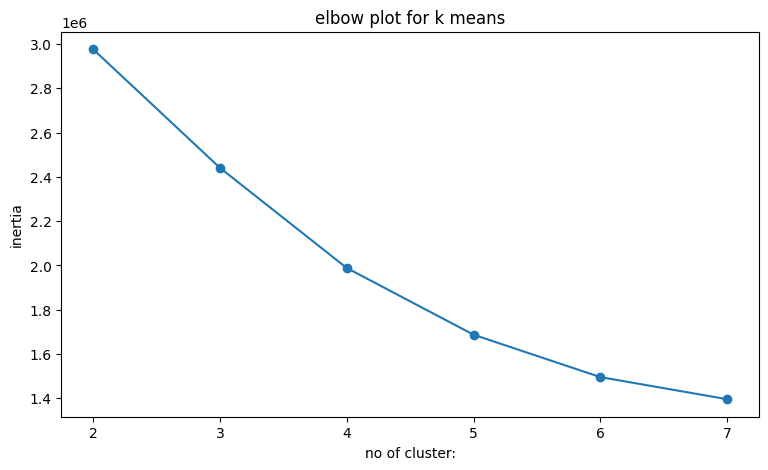

In [ ]:
# elbow plot
plt.figure(figsize=(9,5))
plt.plot(k_value,inertia,marker = 'o')
plt.xlabel("no of cluster:")
plt.ylabel("inertia")
plt.title("elbow plot for k means")
plt.show()

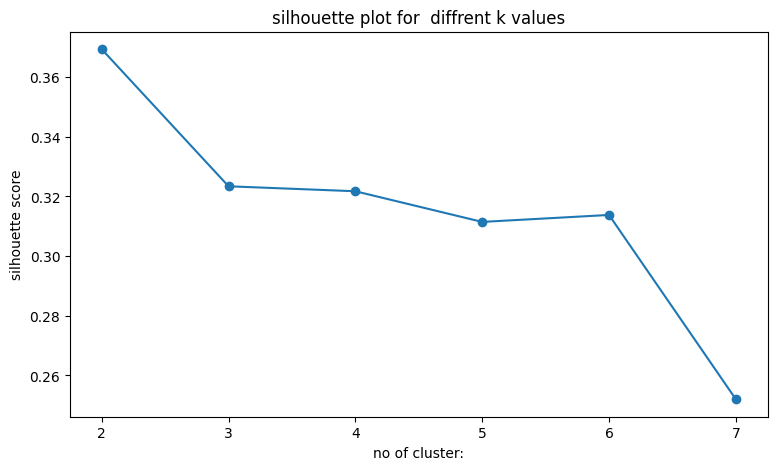

In [ ]:
# silhouette plot
plt.figure(figsize=(9,5))
plt.plot(k_value,silhouette_scores,marker = 'o')
plt.xlabel("no of cluster:")
plt.ylabel("silhouette score")
plt.title("silhouette plot for  diffrent k values")
plt.show()

In [ ]:
# choosing best value for k
result = pd.DataFrame({"k":k_value,"inertia":inertia,"silhouette_scores":silhouette_scores})
result

,k,inertia,silhouette_scores
0,2,2.976619e+06,0.369322
1,3,2.440895e+06,0.323390
2,4,1.988616e+06,0.321728
3,5,1.687132e+06,0.311452
4,6,1.495628e+06,0.313786
5,7,1.395779e+06,0.252034


In [ ]:
# train final k mean model
final_k = 2
kmeans_final = KMeans(n_clusters=final_k,random_state=42,n_init=10)
customer_df['KMeans_cluster'] = kmeans_final.fit_predict(X_scaled)

In [ ]:
# evaluate final k mean by silhouette score
kmean_sample_label = kmeans_final.labels_[sample_index] # contain cluster label for each customer
final_silhouette = silhouette_score(X_sample,kmean_sample_label)
print("final k mean silhouuette score:",round(final_silhouette,4))

final k mean silhouuette score: 0.3693


In [ ]:
# checking cluster size (count total customer in clusters)
cluster_size = customer_df['KMeans_cluster'].value_counts().sort_index()
cluster_size

,count
KMeans_cluster,
0,211625
1,672639


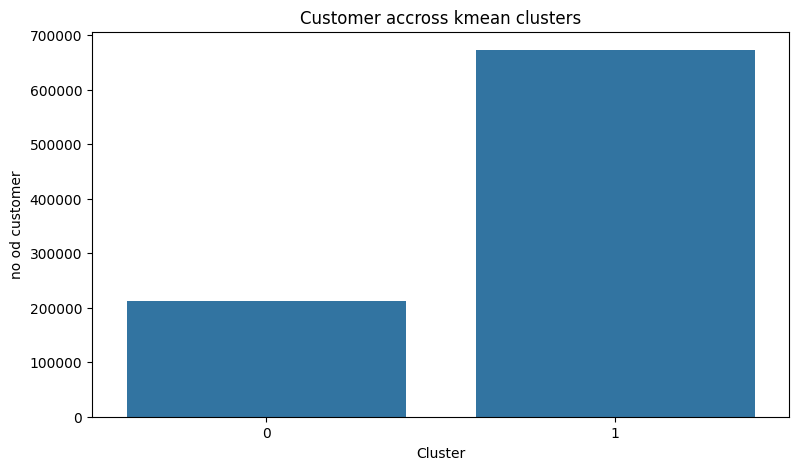

In [ ]:
# plot cluster size
plt.figure(figsize=(9,5))
sns.barplot(x = cluster_size.index,y = cluster_size.values)
plt.title("Customer accross kmean clusters")
plt.xlabel("Cluster")
plt.ylabel("no od customer")
plt.show()

Hierarchical clustering

In [ ]:
# creating linkage using ward
linkage_matrix = linkage(X_sample,method='ward') # ward linkage to create compact similar clusters

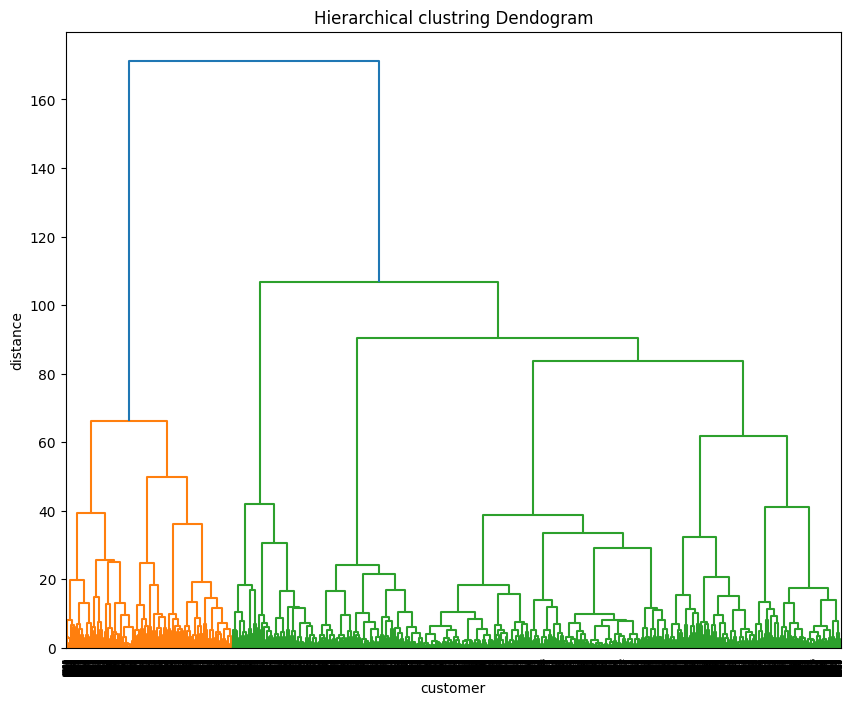

In [ ]:
# plot dendogram
plt.figure(figsize=(10,8))
dendrogram(linkage_matrix)
plt.title("Hierarchical clustring Dendogram")
plt.xlabel("customer")
plt.ylabel("distance")
plt.show()

In [ ]:
# create agglomarative clustring model and train
hierarchical_model = AgglomerativeClustering(n_clusters=final_k,linkage = 'ward')
hierarchical_labels = hierarchical_model.fit_predict(X_sample)

In [ ]:
# assign hierarchical label to sample customer only
customer_df['hierarchical_cluster'] = np.nan
customer_df.loc[customer_df.index[sample_index],'hierarchical_cluster'] = hierarchical_labels

In [ ]:
# Create separate hierarchical DataFrame for non null values
hierarchical_df = customer_df[customer_df["hierarchical_cluster"].notna()].copy()

In [ ]:
# check cluster_size in hierarchical clustring
cluster_size =  hierarchical_df["hierarchical_cluster"].value_counts().sort_index()
cluster_size

,count
hierarchical_cluster,
0.0,7842
1.0,2158


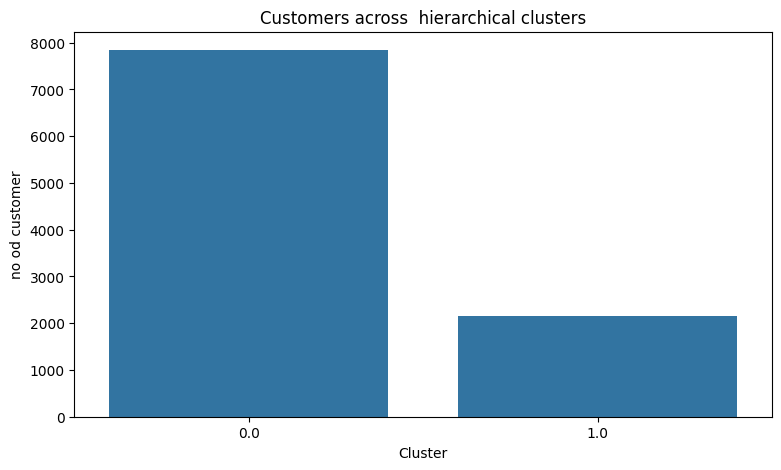

In [ ]:
# plot customer count in each hierarchical cluster
plt.figure(figsize = (9,5))
sns.countplot(data = hierarchical_df,x = 'hierarchical_cluster')
plt.title("Customers across  hierarchical clusters")
plt.xlabel("Cluster")
plt.ylabel("no od customer")
plt.show()

In [ ]:
# calculate silhouette score
hierarchical_silhoutte = silhouette_score(X_sample,hierarchical_labels)
print("hierarchical silhouette score :", round(hierarchical_silhoutte,4))

hierarchical silhouette score : 0.3522


comparing kmean and hierarchical

In [ ]:
# percentage for cluster for kmean and hierarchical model
kmeans_percentage = (customer_df["KMeans_cluster"].value_counts(normalize=True).sort_index() * 100)
hierarchical_percentage = (hierarchical_df["hierarchical_cluster"].value_counts(normalize=True).sort_index() * 100)

In [ ]:
# comparing both model by percentage
comparing = pd.DataFrame({
    "model": ["kmean", "hierarchical"],
    "silhouette_score": [final_silhouette,hierarchical_silhoutte],
    "cluster_0_percentage": [kmeans_percentage.loc[0],hierarchical_percentage.loc[0]],
    "cluster_1_percentage": [kmeans_percentage.loc[1],hierarchical_percentage.loc[1]]
})

comparing

,model,silhouette_score,cluster_0_percentage,cluster_1_percentage
0,kmean,0.369322,23.932332,76.067668
1,hierarchical,0.352221,78.420000,21.580000


### Profiling

hierarchical clustering

In [ ]:
# Calculating average characteristics of each hierarchical cluster
hierarchical_profile = hierarchical_df.groupby("hierarchical_cluster")[numeric_cols].mean()
hierarchical_profile.round(2)

,CustAccountBalance,TOtalTransactionAmount,AverageTransactionAmount,Transactioncount,Age,Recency_days
hierarchical_cluster,,,,,,
0.0,34595.05,557.94,474.4,1.0,28.81,121.72
1.0,60176.68,2814.23,2333.7,1.0,29.35,125.18


In [ ]:
# checking clustring by gender
gender_profile = pd.crosstab(hierarchical_df["hierarchical_cluster"],hierarchical_df["CustGender"],normalize="index") * 100
gender_profile.round(2)

CustGender,0,1
hierarchical_cluster,,
0.0,74.70,25.30
1.0,69.65,30.35


In [ ]:
# checking top 5 location by cluster
for cluster in sorted(hierarchical_df["hierarchical_cluster"].unique()):
    print(f"\nCluster {int(cluster)}")
    print(hierarchical_df[hierarchical_df["hierarchical_cluster"] == cluster]["CustLocation"].value_counts().head(5))


Cluster 0
CustLocation
MUMBAI       767
BANGALORE    632
GURGAON      593
NEW DELHI    584
DELHI        507
Name: count, dtype: int64

Cluster 1
CustLocation
MUMBAI       220
NEW DELHI    192
GURGAON      168
BANGALORE    161
DELHI        141
Name: count, dtype: int64


kmean profiling

In [ ]:
# by gender
kmean_gender_profile = pd.crosstab(customer_df["KMeans_cluster"],customer_df["CustGender"],normalize="index") * 100
kmean_gender_profile.round(2)

CustGender,0,1
KMeans_cluster,,
0,69.80,30.20
1,74.13,25.87


In [ ]:
# Checking top 5 locations by K-Means cluster
for cluster in sorted(customer_df["KMeans_cluster"].unique()):
    print(f"\nK-Means Cluster {int(cluster)}")
    print(customer_df[customer_df["KMeans_cluster"] == cluster]["CustLocation"].value_counts().head(5))


K-Means Cluster 0
CustLocation
MUMBAI       24920
NEW DELHI    20368
GURGAON      15514
BANGALORE    15139
DELHI        14365
Name: count, dtype: int64

K-Means Cluster 1
CustLocation
MUMBAI       62535
BANGALORE    53706
NEW DELHI    51102
GURGAON      46960
DELHI        45539
Name: count, dtype: int64


In [ ]:
# final summary for kmeans customer segmentation
final_profile = (
    customer_df
    .groupby("KMeans_cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Average_Age=("Age", "mean"),
        Average_Balance=("CustAccountBalance", "mean"),
        Average_Total_Transaction=("TOtalTransactionAmount", "mean"),
        Average_Transaction=("AverageTransactionAmount", "mean"),
        Average_Transaction_Count=("Transactioncount", "mean"),
        Average_Recency=("Recency_days", "mean")).round(2)
)
final_profile["Customer_Percentage"] = (final_profile["Customer_Count"] /len(customer_df) * 100).round(2)
final_profile

,Customer_Count,Average_Age,Average_Balance,Average_Total_Transaction,Average_Transaction,Average_Transaction_Count,Average_Recency,Customer_Percentage
KMeans_cluster,,,,,,,,
0,211625,30.01,60879.90,2772.84,2282.64,1.0,120.07,23.93
1,672639,28.49,32648.69,482.32,417.87,1.0,124.26,76.07
